In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
netflix_df = pd.read_csv(r'netflix_titles.csv')
netflix_df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [3]:
netflix_df.columns

Index(['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added',
       'release_year', 'rating', 'duration', 'listed_in', 'description'],
      dtype='object')

check for the basic information

In [4]:
netflix_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


there are a lot of null values in the director, cast and country cols

Task 1: The "Ghost Content" Audit (Missing Values)

In [5]:
round(netflix_df.isna().sum()/len(netflix_df),2)

show_id         0.00
type            0.00
title           0.00
director        0.30
cast            0.09
country         0.09
date_added      0.00
release_year    0.00
rating          0.00
duration        0.00
listed_in       0.00
description     0.00
dtype: float64

removing the unnecessary cols - show_id and description

In [6]:
netflix_df.drop(['show_id','description'],axis=1,inplace=True)

In [7]:
netflix_df.head()

,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in
0,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries
1,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries"
2,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act..."
3,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV"
4,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ..."


Task 2: The Content Type Skew (Descriptive Stats)

In [8]:
netflix_df.groupby(by='type').count()

,title,director,cast,country,date_added,release_year,rating,duration,listed_in
type,,,,,,,,,
Movie,6131,5943,5656,5691,6131,6131,6129,6128,6131
TV Show,2676,230,2326,2285,2666,2676,2674,2676,2676


In [9]:
round(netflix_df.groupby(by='type').size()/len(netflix_df),2)

type
Movie      0.7
TV Show    0.3
dtype: float64

In [10]:
netflix_df['type'].size

8807

In [11]:
len(netflix_df)

8807

70% of netflix catalog is movies

Task 3: The Content Decay Analysis (Dispersion)

checking the dispersion of the releases

In [12]:
rng = netflix_df['release_year'].max() - netflix_df['release_year'].min()
print(f'range of the release year: {rng} years')

range of the release year: 96 years


In [13]:
netflix_df['release_year'].min()

1925

netflix has a catalog ranging from 96 years. from 1925 to 2021 movies.

In [14]:
var = netflix_df['release_year'].var()
print(var)

77.78026646107516


In [15]:
std = netflix_df['release_year'].std()
print(std)

8.819312130833966


(array([1.000e+00, 8.000e+00, 7.000e+00, 2.100e+01, 2.700e+01, 9.900e+01,
        1.500e+02, 2.940e+02, 1.107e+03, 7.093e+03]),
 array([1925. , 1934.6, 1944.2, 1953.8, 1963.4, 1973. , 1982.6, 1992.2,
        2001.8, 2011.4, 2021. ]),
 <BarContainer object of 10 artists>)

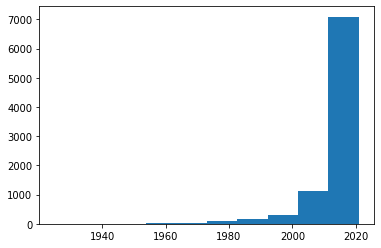

In [16]:
plt.hist(netflix_df['release_year'])

though the catalog spans 100 years, most of the movies are from 2010-2020 (recent movies)

Task 1: The Maturity Profile Audit (Audience Breakdown)

In [17]:
netflix_df['rating'].isna().sum()

4

there are 4 missing values in rating. as the count is very low, will fill these with mode of the rating

In [18]:
mode = netflix_df['rating'].mode()
print(mode)

0    TV-MA
dtype: object


In [19]:
mode[0]

'TV-MA'

In [20]:
netflix_df['rating'].fillna(value = mode[0],inplace = True)

In [21]:
netflix_df['rating'].isna().sum()

0

missing values are handled in rating

In [22]:
netflix_df['rating'].value_counts()

TV-MA       3211
TV-14       2160
TV-PG        863
R            799
PG-13        490
TV-Y7        334
TV-Y         307
PG           287
TV-G         220
NR            80
G             41
TV-Y7-FV       6
NC-17          3
UR             3
74 min         1
66 min         1
84 min         1
Name: rating, dtype: int64

In [23]:
rating = netflix_df['rating'].value_counts(normalize=True)
print(round(rating*100,2))

TV-MA       36.46
TV-14       24.53
TV-PG        9.80
R            9.07
PG-13        5.56
TV-Y7        3.79
TV-Y         3.49
PG           3.26
TV-G         2.50
NR           0.91
G            0.47
TV-Y7-FV     0.07
NC-17        0.03
UR           0.03
74 min       0.01
66 min       0.01
84 min       0.01
Name: rating, dtype: float64


<AxesSubplot:>

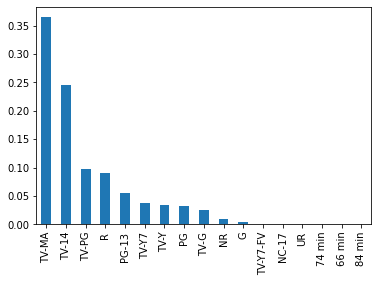

In [24]:
rating.plot(kind='bar')

majority of the shows or movies are for mature audience (around >17 age group). the catalog mostly focuses on trending concepts that appeals these audience

Task 2: The Multi-Variable Audience Matrix (Type vs. Rating)

In [25]:
audience_matrix = pd.crosstab(netflix_df['type'],netflix_df['rating'],normalize=True)
print(round(audience_matrix*100),2)

rating   66 min  74 min  84 min    G  NC-17   NR   PG  PG-13    R  TV-14  \
type                                                                       
Movie       0.0     0.0     0.0  0.0    0.0  1.0  3.0    6.0  9.0   16.0   
TV Show     0.0     0.0     0.0  0.0    0.0  0.0  0.0    0.0  0.0    8.0   

rating   TV-G  TV-MA  TV-PG  TV-Y  TV-Y7  TV-Y7-FV   UR  
type                                                     
Movie     1.0   23.0    6.0   1.0    2.0       0.0  0.0  
TV Show   1.0   13.0    4.0   2.0    2.0       0.0  0.0   2


netflix is pushing its mature content to its short term format (movies) than tv shows. 


Task 3: Visualizing the Core Pillars

In [26]:
import seaborn as sns

<AxesSubplot:xlabel='rating', ylabel='type'>

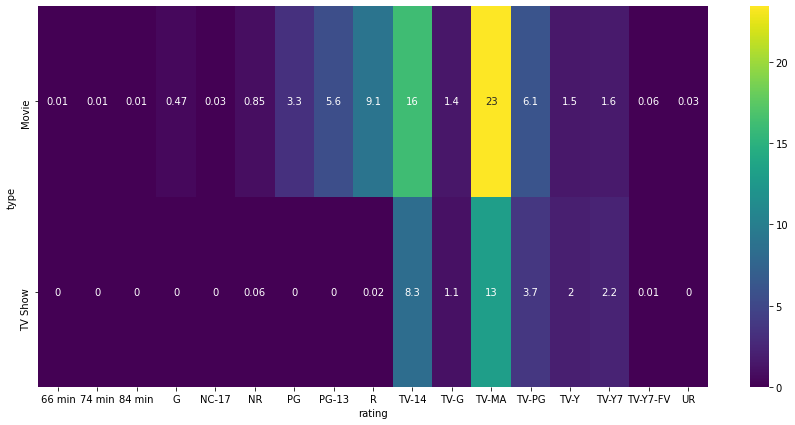

In [27]:
plt.figure(figsize=(15,7))
sns.heatmap(round(audience_matrix*100,2),annot=True,cmap = 'viridis')

netflix has a  share of movies around 70% by volume. 23% out of 70% of movies translates to 33% of TV-MA rating. Where as for Tvshows, 13% out of 30% translates to 43% ot TV-Ma rating. This says netflix is pushing more mature content in tv shows than movies. the catalog caters to various sections of the audiences in the movies than tv shows. most of the tv shows they cater to are TV-Ma and TV14 audiences.

**The Intermediate Playbook (Content Decay & Velocity)**

In [28]:
#converting date into proper datetime format
release_dt = pd.to_datetime(netflix_df['date_added'])
release_dt

0      2021-09-25
1      2021-09-24
2      2021-09-24
3      2021-09-24
4      2021-09-24
          ...    
8802   2019-11-20
8803   2019-07-01
8804   2019-11-01
8805   2020-01-11
8806   2019-03-02
Name: date_added, Length: 8807, dtype: datetime64[ns]

In [29]:
netflix_df['date_added'] = release_dt

In [30]:
netflix_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   type          8807 non-null   object        
 1   title         8807 non-null   object        
 2   director      6173 non-null   object        
 3   cast          7982 non-null   object        
 4   country       7976 non-null   object        
 5   date_added    8797 non-null   datetime64[ns]
 6   release_year  8807 non-null   int64         
 7   rating        8807 non-null   object        
 8   duration      8804 non-null   object        
 9   listed_in     8807 non-null   object        
dtypes: datetime64[ns](1), int64(1), object(8)
memory usage: 688.2+ KB


In [31]:
#creating two cols
netflix_df['year'] = netflix_df['date_added'].dt.year
netflix_df['month'] = netflix_df['date_added'].dt.month

In [32]:
netflix_df.head()

,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,year,month
0,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,2021-09-25,2020,PG-13,90 min,Documentaries,2021.0,9.0
1,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries",2021.0,9.0
2,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,2021-09-24,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",2021.0,9.0
3,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,2021-09-24,2021,TV-MA,1 Season,"Docuseries, Reality TV",2021.0,9.0
4,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",2021.0,9.0


how many titles are added each year?

In [33]:
titles_per_year = netflix_df.groupby('year').count()['type']
titles_per_year

year
2008.0       2
2009.0       2
2010.0       1
2011.0      13
2012.0       3
2013.0      11
2014.0      24
2015.0      82
2016.0     429
2017.0    1188
2018.0    1649
2019.0    2016
2020.0    1879
2021.0    1498
Name: type, dtype: int64

<AxesSubplot:xlabel='year'>

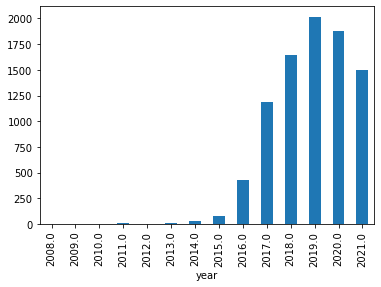

In [34]:
titles_per_year.plot(kind='bar')

though netflix started as streaming service in 2007, they have started adding more titles from 2016 coz it announced its expansion n 130 countries in 2016. 2019 saw the spike where more titles added ever due to lockdown. it helped all of us cope up during lockdown by adding more titles which indirectly relates to more viewership.
Upto 2021, their acquisition of the titles increased by 2021 compared to initial stages. As the lockdown is off, their velocity decreased bit.

**Advanced Strategies**

Genre explosion

In [35]:
netflix_df['listed_in'].value_counts()

Dramas, International Movies                        362
Documentaries                                       359
Stand-Up Comedy                                     334
Comedies, Dramas, International Movies              274
Dramas, Independent Movies, International Movies    252
                                                   ... 
Classic Movies, Comedies, Romantic Movies             1
Cult Movies, Dramas, International Movies             1
Classic Movies, Music & Musicals                      1
TV Sci-Fi & Fantasy, TV Thrillers                     1
Sports Movies                                         1
Name: listed_in, Length: 514, dtype: int64

since one movie has multiple genres, lets split the genres and map movies against each

In [36]:
netflix_df['listed_in']=netflix_df['listed_in'].str.split(', ')

In [37]:
netflix_df.head()

,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,year,month
0,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,2021-09-25,2020,PG-13,90 min,[Documentaries],2021.0,9.0
1,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021-09-24,2021,TV-MA,2 Seasons,"[International TV Shows, TV Dramas, TV Mysteries]",2021.0,9.0
2,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,2021-09-24,2021,TV-MA,1 Season,"[Crime TV Shows, International TV Shows, TV Ac...",2021.0,9.0
3,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,2021-09-24,2021,TV-MA,1 Season,"[Docuseries, Reality TV]",2021.0,9.0
4,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,2021-09-24,2021,TV-MA,2 Seasons,"[International TV Shows, Romantic TV Shows, TV...",2021.0,9.0


In [38]:
genre_df = netflix_df.explode('listed_in')

In [39]:
titles_by_genres = genre_df['listed_in'].value_counts()

<AxesSubplot:>

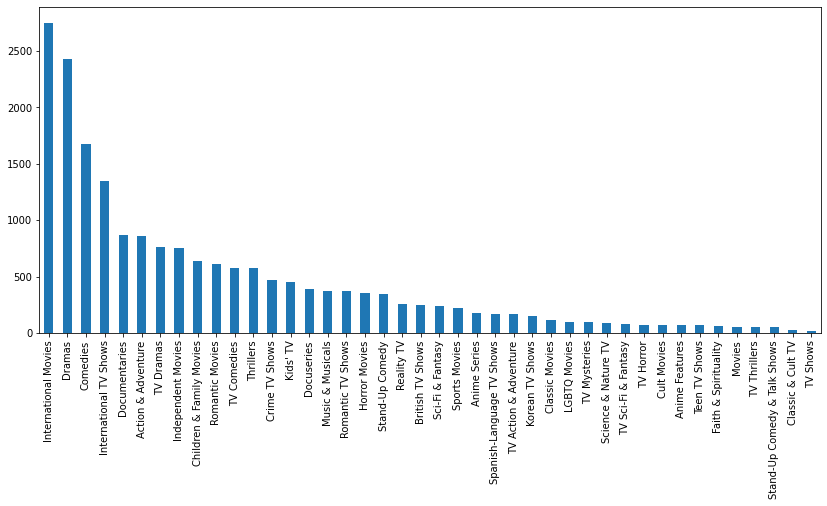

In [40]:
plt.figure(figsize=(14,6))
titles_by_genres.plot(kind='bar')

netflix has around 2500+ international movies catalog compared to other genres. This is part of their strategy to cater and survive their expansion in 130 countries and retain subscribers across various nations. we see very less TV shows and Movies as genre, this might be incorrect tagging or emergence of new tv genres.

In [41]:
netflix_df

,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,year,month
0,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,2021-09-25,2020,PG-13,90 min,[Documentaries],2021.0,9.0
1,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021-09-24,2021,TV-MA,2 Seasons,"[International TV Shows, TV Dramas, TV Mysteries]",2021.0,9.0
2,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,2021-09-24,2021,TV-MA,1 Season,"[Crime TV Shows, International TV Shows, TV Ac...",2021.0,9.0
3,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,2021-09-24,2021,TV-MA,1 Season,"[Docuseries, Reality TV]",2021.0,9.0
4,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,2021-09-24,2021,TV-MA,2 Seasons,"[International TV Shows, Romantic TV Shows, TV...",2021.0,9.0
...,...,...,...,...,...,...,...,...,...,...,...,...
8802,Movie,Zodiac,David Fincher,"Mark Ruffalo, Jake Gyllenhaal, Robert Downey J...",United States,2019-11-20,2007,R,158 min,"[Cult Movies, Dramas, Thrillers]",2019.0,11.0
8803,TV Show,Zombie Dumb,NaN,NaN,NaN,2019-07-01,2018,TV-Y7,2 Seasons,"[Kids' TV, Korean TV Shows, TV Comedies]",2019.0,7.0
8804,Movie,Zombieland,Ruben Fleischer,"Jesse Eisenberg, Woody Harrelson, Emma Stone, ...",United States,2019-11-01,2009,R,88 min,"[Comedies, Horror Movies]",2019.0,11.0
8805,Movie,Zoom,Peter Hewitt,"Tim Allen, Courteney Cox, Chevy Chase, Kate Ma...",United States,2020-01-11,2006,PG,88 min,"[Children & Family Movies, Comedies]",2020.0,1.0


**Tier 5: Content Longevity & Binge-Watching Engineering**

In [43]:
movies_df = netflix_df[netflix_df['type']=='Movie']
movies_df.head()

,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,year,month
0,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,2021-09-25,2020,PG-13,90 min,[Documentaries],2021.0,9.0
6,Movie,My Little Pony: A New Generation,"Robert Cullen, José Luis Ucha","Vanessa Hudgens, Kimiko Glenn, James Marsden, ...",NaN,2021-09-24,2021,PG,91 min,[Children & Family Movies],2021.0,9.0
7,Movie,Sankofa,Haile Gerima,"Kofi Ghanaba, Oyafunmike Ogunlano, Alexandra D...","United States, Ghana, Burkina Faso, United Kin...",2021-09-24,1993,TV-MA,125 min,"[Dramas, Independent Movies, International Mov...",2021.0,9.0
9,Movie,The Starling,Theodore Melfi,"Melissa McCarthy, Chris O'Dowd, Kevin Kline, T...",United States,2021-09-24,2021,PG-13,104 min,"[Comedies, Dramas]",2021.0,9.0
12,Movie,Je Suis Karl,Christian Schwochow,"Luna Wedler, Jannis Niewöhner, Milan Peschel, ...","Germany, Czech Republic",2021-09-23,2021,TV-MA,127 min,"[Dramas, International Movies]",2021.0,9.0


In [70]:
#converting the duration into int for the avg
movies_df['duration'].isna().sum()

3

In [73]:
movies_df[['dur','dur_unit']]=movies_df['duration'].str.split(' ',n=1,expand=True)

c:\users\91738\appdata\local\programs\python\python39\lib\site-packages\pandas\core\frame.py:3191: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  self[k1] = value[k2]


In [74]:
movies_df.head()

,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,year,month,dur,dur_unit
0,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,2021-09-25,2020,PG-13,90 min,[Documentaries],2021.0,9.0,90,min
6,Movie,My Little Pony: A New Generation,"Robert Cullen, José Luis Ucha","Vanessa Hudgens, Kimiko Glenn, James Marsden, ...",NaN,2021-09-24,2021,PG,91 min,[Children & Family Movies],2021.0,9.0,91,min
7,Movie,Sankofa,Haile Gerima,"Kofi Ghanaba, Oyafunmike Ogunlano, Alexandra D...","United States, Ghana, Burkina Faso, United Kin...",2021-09-24,1993,TV-MA,125 min,"[Dramas, Independent Movies, International Mov...",2021.0,9.0,125,min
9,Movie,The Starling,Theodore Melfi,"Melissa McCarthy, Chris O'Dowd, Kevin Kline, T...",United States,2021-09-24,2021,PG-13,104 min,"[Comedies, Dramas]",2021.0,9.0,104,min
12,Movie,Je Suis Karl,Christian Schwochow,"Luna Wedler, Jannis Niewöhner, Milan Peschel, ...","Germany, Czech Republic",2021-09-23,2021,TV-MA,127 min,"[Dramas, International Movies]",2021.0,9.0,127,min


In [85]:
#converting dur to numeric
movies_df['dur']=pd.to_numeric(movies_df['dur'],errors='coerce').astype('Int64')

C:\Users\91738\AppData\Local\Temp\ipykernel_3332\1451089251.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  movies_df['dur']=pd.to_numeric(movies_df['dur'],errors='coerce').astype('Int64')


In [86]:
movies_avg_dur = movies_df['dur'].mean()
movies_avg_dur

99.57718668407311

In [89]:
movies_df['dur'].dtype

Int64Dtype()

In [91]:
movies_df['dur'].fillna(int(movies_avg_dur),inplace=True)

c:\users\91738\appdata\local\programs\python\python39\lib\site-packages\pandas\core\series.py:4463: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  return super().fillna(


In [94]:
movies_df['dur'].isna().sum()

0

lets create a duration bucket and distribute the movies across it

(array([3.340e+02, 1.380e+03, 3.095e+03, 9.360e+02, 2.130e+02, 4.600e+01,
        1.000e+00, 1.000e+00]),
 array([ 30,  60,  90, 120, 150, 180, 240, 270, 300]),
 <BarContainer object of 8 artists>)

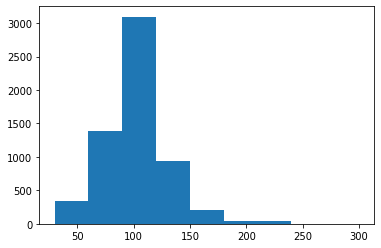

In [100]:
plt.hist(movies_df['dur'],bins=[30,60,90,120,150,180,240,270,300])

majority of the movies span between 90 and 120 mins. there are movies that are less than 30 mins long all the way to 3 mins. there are movies that are nearly 240 mins long( 4 hrs). bandersnatch is the interactive movie that takes long time to complete (around 5 hrs).

In [109]:
movies_df[['title','dur','year']].sort_values(by='dur')

,title,dur,year
3777,Silent,3,2019.0
2713,Sol Levante,5,2020.0
1484,Cops and Robbers,8,2020.0
1557,Canvas,9,2020.0
3535,American Factory: A Conversation with the Obamas,10,2019.0
...,...,...,...
2484,Lock Your Girls In,233,2020.0
2487,No Longer kids,237,2020.0
2491,The School of Mischief,253,2020.0
717,Headspace: Unwind Your Mind,273,2021.0


In [110]:
tv_df = netflix_df[netflix_df['type']=='TV Show']
tv_df.head()

,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,year,month
1,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021-09-24,2021,TV-MA,2 Seasons,"[International TV Shows, TV Dramas, TV Mysteries]",2021.0,9.0
2,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,2021-09-24,2021,TV-MA,1 Season,"[Crime TV Shows, International TV Shows, TV Ac...",2021.0,9.0
3,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,2021-09-24,2021,TV-MA,1 Season,"[Docuseries, Reality TV]",2021.0,9.0
4,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,2021-09-24,2021,TV-MA,2 Seasons,"[International TV Shows, Romantic TV Shows, TV...",2021.0,9.0
5,TV Show,Midnight Mass,Mike Flanagan,"Kate Siegel, Zach Gilford, Hamish Linklater, H...",NaN,2021-09-24,2021,TV-MA,1 Season,"[TV Dramas, TV Horror, TV Mysteries]",2021.0,9.0


In [114]:
tv_df[['dur','dur_unit']] = tv_df['duration'].str.split(' ',n=1,expand=True)
tv_df.head()

,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,year,month,dur,dur_unit
1,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021-09-24,2021,TV-MA,2 Seasons,"[International TV Shows, TV Dramas, TV Mysteries]",2021.0,9.0,2,Seasons
2,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,2021-09-24,2021,TV-MA,1 Season,"[Crime TV Shows, International TV Shows, TV Ac...",2021.0,9.0,1,Season
3,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,2021-09-24,2021,TV-MA,1 Season,"[Docuseries, Reality TV]",2021.0,9.0,1,Season
4,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,2021-09-24,2021,TV-MA,2 Seasons,"[International TV Shows, Romantic TV Shows, TV...",2021.0,9.0,2,Seasons
5,TV Show,Midnight Mass,Mike Flanagan,"Kate Siegel, Zach Gilford, Hamish Linklater, H...",NaN,2021-09-24,2021,TV-MA,1 Season,"[TV Dramas, TV Horror, TV Mysteries]",2021.0,9.0,1,Season


In [116]:
tv_df['dur'].isna().sum()

0

In [121]:
tv_df['dur']=tv_df['dur'].astype(int)

C:\Users\91738\AppData\Local\Temp\ipykernel_3332\3061802493.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  tv_df['dur']=tv_df['dur'].astype(int)


In [128]:
tv_df['dur'].mode()

0    1
dtype: int32

In [130]:
mode_seasons = tv_df['dur'].mode()[0]
mode_seasons

1

mode of no of seasons is 1

(array([2.218e+03, 2.940e+02, 6.500e+01, 5.600e+01, 1.700e+01, 1.600e+01,
        4.000e+00, 3.000e+00, 2.000e+00, 1.000e+00]),
 array([ 1. ,  2.6,  4.2,  5.8,  7.4,  9. , 10.6, 12.2, 13.8, 15.4, 17. ]),
 <BarContainer object of 10 artists>)

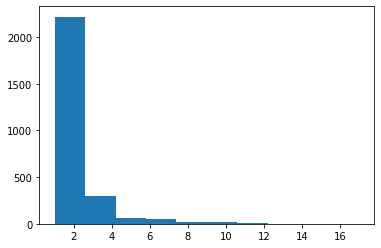

In [131]:
plt.hist(tv_df['dur'])

the seasons distribution is right skewed. around 2100+ tv shows has only 1 or 2 seasons. only a few tv shows has 10 and above seasons. the very long duration tv shows (many seasons) is not so profitable. so it focussed more on tv shows with limited seasons as 1 or 2.

In [133]:
tv_df['dur'].value_counts(normalize=True)

1     0.670030
2     0.158819
3     0.074365
4     0.035501
5     0.024290
6     0.012332
7     0.008595
8     0.006353
9     0.003363
10    0.002616
13    0.001121
12    0.000747
11    0.000747
15    0.000747
17    0.000374
Name: dur, dtype: float64

67% of the tv shows are short lived - 1 season. if limited season indicates to short lived then it is in aligned.